# 08 — SVGC Augmentation


## Section 1: Install Dependencies and Mount Drive

In [1]:
!pip install ultralytics albumentations matplotlib -q

from google.colab import drive
from pathlib import Path
import os

drive.mount('/content/drive')

candidate_paths = [
    Path('/content/drive/MyDrive/uav-small-object-detector'),
    Path('/content/drive/MyDrive/uav-small-object-detector/UAV_small_obj_detector'),
    Path('/content/drive/MyDrive/UAV_small_obj_detector'),
]

project_root = next((path for path in candidate_paths if path.exists()), None)
if project_root is None:
    raise FileNotFoundError(
        'Could not find the project folder in Google Drive. '
        'Check MyDrive/uav-small-object-detector and MyDrive/UAV_small_obj_detector.'
    )

os.chdir(project_root)
print(f'Working directory: {project_root}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.3 MB/s eta 0:00:00
Mounted at /content/drive
Working directory: /content/drive/MyDrive/UAV_small_obj_detector


## Section 2: Load SVGC Module

In [2]:
import sys
sys.path.insert(0, '.')
from src.svgc import apply_svgc, SVGC
import cv2, numpy as np
print('SVGC module loaded successfully.')

SVGC module loaded successfully.


## Section 3: Restore VisDrone Dataset If Needed

In [3]:
from pathlib import Path
import os
import shutil
from PIL import Image
from ultralytics.utils.downloads import download

dataset_root = Path('/content/VisDrone')

def visdrone2yolo(root, split, source_name):
    source_dir = root / source_name
    images_dir = root / 'images' / split
    labels_dir = root / 'labels' / split
    images_dir.mkdir(parents=True, exist_ok=True)
    labels_dir.mkdir(parents=True, exist_ok=True)

    for img in (source_dir / 'images').glob('*.jpg'):
        shutil.move(str(img), str(images_dir / img.name))

    for ann in (source_dir / 'annotations').glob('*.txt'):
        img_path = images_dir / ann.with_suffix('.jpg').name
        img_w, img_h = Image.open(img_path).size
        dw, dh = 1.0 / img_w, 1.0 / img_h
        lines = []

        with open(ann, encoding='utf-8') as f:
            for row in [x.split(',') for x in f.read().strip().splitlines()]:
                if row[4] != '0':
                    x, y, w, h = map(int, row[:4])
                    cls = int(row[5]) - 1
                    x_center = (x + w / 2) * dw
                    y_center = (y + h / 2) * dh
                    w_norm = w * dw
                    h_norm = h * dh
                    lines.append(f'{cls} {x_center:.6f} {y_center:.6f} {w_norm:.6f} {h_norm}\n')

        with open(labels_dir / ann.name, 'w', encoding='utf-8') as out:
            out.writelines(lines)

if not (dataset_root / 'images' / 'val').exists():
    urls = [
        'https://github.com/ultralytics/assets/releases/download/v0.0.0/VisDrone2019-DET-train.zip',
        'https://github.com/ultralytics/assets/releases/download/v0.0.0/VisDrone2019-DET-val.zip',
        'https://github.com/ultralytics/assets/releases/download/v0.0.0/VisDrone2019-DET-test-dev.zip',
    ]
    download(urls, dir=dataset_root, threads=4)

    for folder, split in {
        'VisDrone2019-DET-train': 'train',
        'VisDrone2019-DET-val': 'val',
        'VisDrone2019-DET-test-dev': 'test',
    }.items():
        visdrone2yolo(dataset_root, split, folder)
        shutil.rmtree(dataset_root / folder)

print('Train images:', len(os.listdir('/content/VisDrone/images/train')))
print('Val images:', len(os.listdir('/content/VisDrone/images/val')))

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Unzipping /content/VisDrone/VisDrone2019-DET-val.zip to /content/VisDrone/VisDrone2019-DET-val...: 100% ━━━━━━━━━━━━ 1099/1099 235.0files/s 4.7s
Unzipping /content/VisDrone/VisDrone2019-DET-test-dev.zip to /content/VisDrone/VisDrone2019-DET-test-dev...: 100% ━━━━━━━━━━━━ 3223/3223 271.3files/s 11.9s
Unzipping /content/VisDrone/VisDrone2019-DET-train.zip to /content/VisDrone/VisDrone2019-DET-train...: 100% ━━━━━━━━━━━━ 12945/12945 962.9files/s 13.4s
Train images: 6471
Val images: 548


## Section 4: Visualize SVGC Augmentation (sanity check)

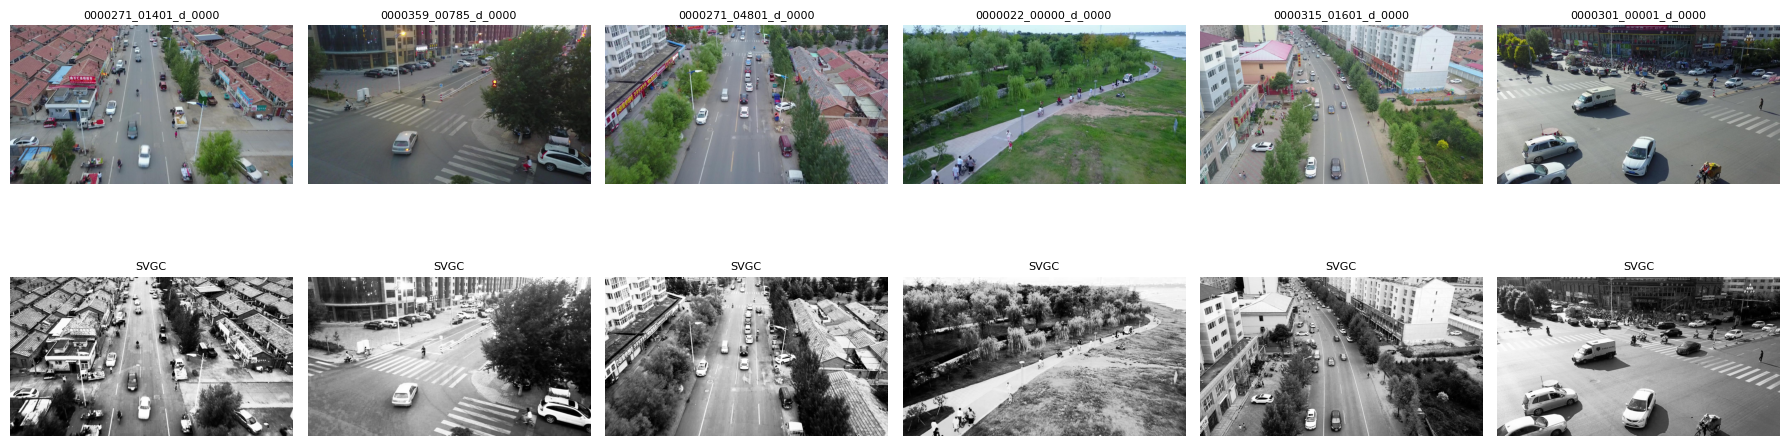

In [4]:
import matplotlib.pyplot as plt
import random
val_images = list(Path('/content/VisDrone/images/val').glob('*.jpg'))
sample_images = random.sample(val_images, 6)

fig, axes = plt.subplots(2, 6, figsize=(18, 6))
for i, img_path in enumerate(sample_images):
    img_bgr = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_aug = apply_svgc(img_rgb, p=1.0)

    axes[0, i].imshow(img_rgb)
    axes[0, i].axis('off')
    axes[0, i].set_title(img_path.name[:20], fontsize=8)

    axes[1, i].imshow(img_aug)
    axes[1, i].axis('off')
    axes[1, i].set_title('SVGC', fontsize=8)

plt.tight_layout()
plt.savefig('results/svgc_samples.png', dpi=150)
plt.show()

## Section 5: Load CBAM Trained Weights

In [5]:
weight_candidates = sorted(project_root.glob('runs/detect/cbam_visdrone*/weights/best.pt'))
if not weight_candidates:
    raise FileNotFoundError('Could not find CBAM weights...')
cbam_weight = weight_candidates[-1]
print('CBAM weights loaded from:', cbam_weight)

CBAM weights loaded from: /content/drive/MyDrive/UAV_small_obj_detector/runs/detect/cbam_visdrone/weights/best.pt


## Section 6: Configure SVGC Augmentation and CBAM Hook and training


In [6]:
from ultralytics import YOLO
import torch
import numpy as np
import sys
sys.path.insert(0, '.')
from src.cbam import CBAM
from src.svgc import apply_svgc

model = YOLO(str(cbam_weight))

# --- 1. CONFIGURE SVGC AUGMENTATION CALLBACK ---
def svgc_augment_callback(trainer):
    """Apply SVGC to the current training batch with our optimized settings."""
    if hasattr(trainer, 'batch') and trainer.batch is not None:
        imgs = trainer.batch['img']
        device = imgs.device
        imgs_np = (imgs.cpu().numpy() * 255).astype(np.uint8)
        imgs_np = imgs_np.transpose(0, 2, 3, 1)  # BGR order
        for i in range(len(imgs_np)):
            rgb = imgs_np[i][:, :, ::-1].copy()   # BGR -> RGB
            rgb_aug = apply_svgc(rgb, p=0.25)
            imgs_np[i] = rgb_aug[:, :, ::-1]       # back to BGR
        imgs_aug = torch.from_numpy(
            imgs_np.transpose(0, 3, 1, 2).astype(np.float32) / 255.0
        ).to(device)
        trainer.batch['img'] = imgs_aug

model.add_callback('on_train_batch_start', svgc_augment_callback)
print('SVGC callback successfully (p=0.25)!')

target_idx = 9
class ShapeProbe(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.shape = None
    def forward(self, x):
        self.shape = x.shape
        return x

probe = ShapeProbe()
temp_hook = model.model.model[target_idx].register_forward_hook(lambda m, i, o: probe(o))
_ = model.model(torch.zeros(1, 3, 640, 640).to(model.device))
temp_hook.remove()
in_channels = probe.shape[1]

# --- 3. ATTACH CBAM HOOK ---
device = model.device
cbam_module = CBAM(in_channels=in_channels).to(device)

def cbam_hook(module, input, output):
    return cbam_module(output)

hook = model.model.model[target_idx].register_forward_hook(cbam_hook)
print(f'CBAM hook successfully re-attached to layer {target_idx}!')

print('Starting CBAM + SVGC')
model.train(
    data='visdrone.yaml',
    epochs=30,

#    patience=5, removed this as it stopped on 6 epochs and yeah the performance was worse than baseline YOLO
    name='cbam_svgc_visdrone',
    save_period=5
)

hook.remove()
print('Training complete! CBAM hook removed.')


SVGC callback successfully (p=0.25)!
CBAM hook successfully re-attached to layer 9!
Starting CBAM + SVGC
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=visdrone.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/UAV_small_obj_detector/runs/detect/cbam_visdrone/wei

In [12]:
from ultralytics import YOLO

# 1. Load the 30-epoch weights
model = YOLO('runs/detect/cbam_svgc_visdrone-5/weights/last.pt')

# 2. Re-register the SVGC callback
model.add_callback('on_train_batch_start', svgc_augment_callback)

# 3. Re-attach the CBAM hook
hook = model.model.model[target_idx].register_forward_hook(cbam_hook)

# Running 5 more epochs (just in case tbh)
print("🚀 Polishing for exactly 5 more epochs...")
model.train(
    data='visdrone.yaml',
    epochs=5,
    name='cbam_svgc_final_polish'
)

# 5. Run Evaluation immediately after
hook.remove()
metrics = model.val()
print(f"Final mAP@50 after 35 total epochs: {metrics.box.map50:.4f}")


🚀 Polishing for exactly 5 more epochs...
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=visdrone.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=runs/detect/cbam_svgc_visdrone-5/weights/last.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=cbam_svgc_final_polish, nbs=64, nms=Fals

## Section 8: Evaluate SVGC Model

In [22]:
svgc_metrics = model.val()
svgc_map50 = float(svgc_metrics.box.map50)
svgc_map50_95 = float(svgc_metrics.box.map)
svgc_precision = float(svgc_metrics.box.mp)
svgc_recall = float(svgc_metrics.box.mr)
print(f'SVGC mAP@50:    {svgc_map50:.4f}')
print(f'SVGC mAP@50-95: {svgc_map50_95:.4f}')

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1904.5±577.9 MB/s, size: 133.3 KB)
val: Scanning /content/VisDrone/labels/val.cache... 548 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 548/548 191.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 35/35 3.0it/s 11.6s
                   all        548      38759      0.431      0.324        0.3      0.168
            pedestrian        520       8844      0.399      0.361      0.313      0.124
                people        482       5125      0.497      0.228      0.231     0.0778
               bicycle        364       1287      0.198     0.0979     0.0612     0.0237
                   car        515      14064      0.607      0.746      0.721      0.471
                   van        421       1975       0.44      0.358      0.337      0.228
                 truck        266     

## Section 9: Save SVGC Metrics to JSON

In [23]:
import json
metrics_path = Path('results/metrics.json')
if metrics_path.exists():
    with open(metrics_path, 'r', encoding='utf-8') as f:
        all_metrics = json.load(f)
else:
    all_metrics = {}

all_metrics['svgc'] = {
    'mAP50': svgc_map50,
    'mAP50-95': svgc_map50_95,
    'precision': svgc_precision,
    'recall': svgc_recall
}

with open(metrics_path, 'w', encoding='utf-8') as f:
    json.dump(all_metrics, f, indent=2)

print('SVGC metrics saved.')
print(json.dumps(all_metrics, indent=2))

SVGC metrics saved.
{
  "baseline": {
    "mAP50": 0.29373669317784457,
    "mAP50-95": 0.1662671086264691,
    "precision": 0.39159907325051424,
    "recall": 0.30258304542539205
  },
  "cbam": {
    "mAP50": 0.30206881342972747,
    "mAP50-95": 0.17270067683582924,
    "precision": 0.414643359389183,
    "recall": 0.3024832252138724
  },
  "pseudo_label": {
    "mAP50": 0.3072394253534811,
    "mAP50-95": 0.1755445358297251,
    "precision": 0.4185700011011811,
    "recall": 0.3119329290737634,
    "accepted": 100,
    "rejected": 0,
    "acceptance_rate": 100.0,
    "weights": "/content/drive/MyDrive/UAV_small_obj_detector/runs/detect/pseudo_label_visdrone/weights/best.pt"
  },
  "yolov11n_baseline": {
    "mAP50": 0.2651762490537308,
    "mAP50-95": 0.14755468472085892,
    "precision": 0.38817470697606105,
    "recall": 0.3011898452484491
  },
  "yolo26n_baseline": {
    "mAP50": 0.24941439738801044,
    "mAP50-95": 0.13737889200958459,
    "precision": 0.36771093891145196,
    "r

## Section 10: Generate CBAM vs SVGC Comparison Chart

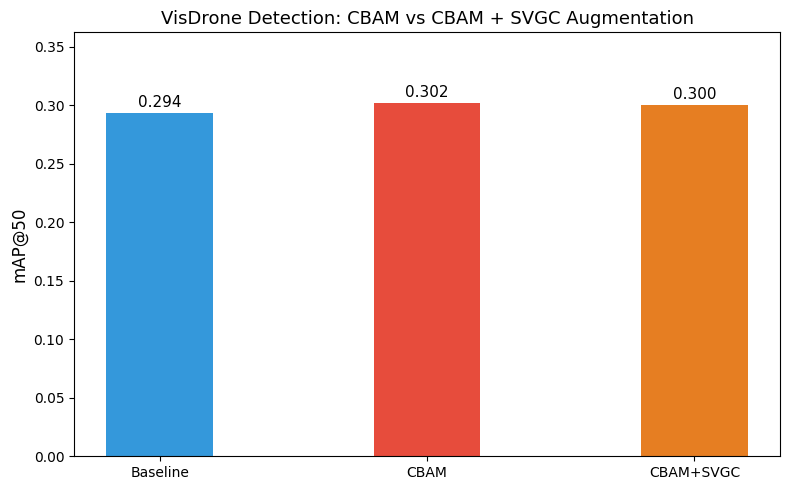

Chart saved to results/svgc_comparison.png


In [24]:
import matplotlib.pyplot as plt
baseline_map50 = all_metrics.get('baseline', {}).get('mAP50', 0)
cbam_map50 = all_metrics.get('cbam', {}).get('mAP50', 0)
svgc_map50 = all_metrics.get('svgc', {}).get('mAP50', 0)

models = ['Baseline', 'CBAM', 'CBAM+SVGC']
map50 = [baseline_map50, cbam_map50, svgc_map50]

plt.figure(figsize=(8, 5))
bars = plt.bar(models, map50, color=['#3498db', '#e74c3c', '#e67e22'], width=0.4)
plt.ylabel('mAP@50', fontsize=12)
plt.title('VisDrone Detection: CBAM vs CBAM + SVGC Augmentation', fontsize=13)
plt.ylim(0, max(map50) * 1.2)
for bar, v in zip(bars, map50):
    plt.text(bar.get_x() + bar.get_width()/2, v + 0.005,
             f'{v:.3f}', ha='center', fontsize=11)
plt.tight_layout()
plt.savefig('results/svgc_comparison.png', dpi=150)
plt.show()
print('Chart saved to results/svgc_comparison.png')

## Section 11: Results Summary

| Model | mAP@50 | Change |
|---|---|---|
| Baseline | To be updated | - |
| CBAM | To be updated | To be updated |
| CBAM+SVGC | To be updated | To be updated |

**Note:** SVGC equalizes the histogram of the Value channel (HSV) to simulate grayscale/IR modality, improving generalization. Source: Gautam et al., RGB-IR Object Detection in Aerial Imagery via Spectral-Aware Augmentation Techniques, IIT Goa, ETAAV 2025.

**Next step:** run `metrics_comparision.ipynb` for full comparison.